In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

hngliththu_user_video_raw_path = kagglehub.dataset_download('hngliththu/user-video-raw')

print('Data source import complete.')


In [ ]:
pip install polars

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import polars as pl
import os
import json
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import requests

user_video_df = pl.read_ndjson("/kaggle/input/user-video-raw")
user_video_df.head()

seq,user_id
list[struct[2]],str
"[{""V_1395633"",[{130.0,190.0,1.0,1588431144}, {220.0,250.0,1.0,1588431234}, … {655.1,692.55,1.25,1588437514}]}, {""V_1395635"",[{135.0,170.0,1.0,1588438045}]}, … {""V_6210800"",[{6.0,13.5,1.5,1601012899}]}]","""U_112"""
"[{""V_6224262"",[{286.0,506.0,2.0,1604061626}]}]","""U_150"""
"[{""V_6432959"",[{4552.1,4556.8,1.0,1598192594}]}]","""U_172"""
"[{""V_6334508"",[{4.0,109.0,1.0,1598832781}, {119.0,254.0,1.0,1598832896}]}, {""V_6334516"",[{593.0,598.0,1.0,1598834837}]}, … {""V_6254676"",[{5.0,105.0,1.0,1603849805}]}]","""U_189"""
"[{""V_1358540"",[{59.747,64.747,1.0,1582184174}, {69.795,74.795,1.0,1582184184}, … {584.751,589.751,1.0,1582186212}]}, {""V_1358542"",[{124.588,129.588,1.0,1582186455}, {194.608,199.608,1.0,1582186525}, … {579.763,584.763,1.0,1582186910}]}, … {""V_1358782"",[{350.2,395.3,1.5,1587530324}, {492.6,95.4,1.5,1587530419}]}]","""U_197"""


In [ ]:
user_video_df.schema

Schema([('seq',
         List(Struct({'video_id': String, 'segment': List(Struct({'start_point': Float64, 'end_point': Float64, 'speed': Float64, 'local_start_time': Int64}))}))),
        ('user_id', String)])

In [ ]:
# Tách từng phần tử trong danh sách seq (mỗi video)
video_expanded_df = user_video_df.explode("seq")

# Lấy ra video_id và danh sách các segment
video_details_df = video_expanded_df.with_columns(
    pl.col("seq").struct.field("video_id").alias("video_id"),
    pl.col("seq").struct.field("segment").alias("segments_list")
).drop("seq")

# Làm phẳng các segment trong mỗi video
final_flat_df = video_details_df.explode("segments_list")

# Tách từng thuộc tính trong segment
final_flat_df = final_flat_df.with_columns(
    pl.col("segments_list").struct.field("start_point").alias("start_point"),
    pl.col("segments_list").struct.field("end_point").alias("end_point"),
    pl.col("segments_list").struct.field("speed").alias("playback_speed"),
    pl.col("segments_list").struct.field("local_start_time").alias("timestamp")
).drop("segments_list")

print("Đã làm phẳng dữ liệu:", final_flat_df.shape)
final_flat_df.head()

Đã làm phẳng dữ liệu: (25748664, 6)


user_id,video_id,start_point,end_point,playback_speed,timestamp
str,str,f64,f64,f64,i64
"""U_112""","""V_1395633""",130.0,190.0,1.0,1588431144
"""U_112""","""V_1395633""",220.0,250.0,1.0,1588431234
"""U_112""","""V_1395633""",478.8,508.8,1.0,1588437359
"""U_112""","""V_1395633""",655.1,692.55,1.25,1588437514
"""U_112""","""V_1395635""",135.0,170.0,1.0,1588438045


In [ ]:
print(final_flat_df.schema)

Schema([('user_id', String), ('video_id', String), ('start_point', Float64), ('end_point', Float64), ('playback_speed', Float64), ('timestamp', Int64)])


In [ ]:
final_flat_df.describe()

statistic,user_id,video_id,start_point,end_point,playback_speed,timestamp
str,str,str,f64,f64,f64,f64
"""count""","""25748664""","""25748664""",2.5748664e7,2.5748664e7,2.5748664e7,2.5748664e7
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",null,null,448.052778,466.846236,1.177257,1.5998e9
"""std""",null,null,631.256707,2372.182958,0.366499,6.1924e6
"""min""","""U_10001181""","""V_1000004""",0.0,-2.0239e6,0.5,1.0098e9
"""25%""",null,null,144.7,170.0,1.0,1.5989e9
"""50%""",null,null,332.0,356.0,1.0,1.6017e9
"""75%""",null,null,585.0,606.0,1.0,1.6036e9
"""max""","""U_9999820""","""V_999993""",69209.6,48921.0,2.0,3.4855e9


In [ ]:
# Thêm cột datetime_utc
final_flat_df = final_flat_df.with_columns(
    (pl.from_epoch("timestamp", time_unit="s")
     .dt.replace_time_zone("Asia/Shanghai")  # gốc là giờ Trung Quốc
     .dt.convert_time_zone("UTC")            # chuyển về UTC
     .alias("datetime_utc"))
)

print("Đã thêm cột datetime_utc:")
final_flat_df.select(["timestamp", "datetime_utc"]).head()


Đã thêm cột datetime_utc:


timestamp,datetime_utc
i64,"datetime[μs, UTC]"
1588431144,2020-05-02 06:52:24 UTC
1588431234,2020-05-02 06:53:54 UTC
1588437359,2020-05-02 08:35:59 UTC
1588437514,2020-05-02 08:38:34 UTC
1588438045,2020-05-02 08:47:25 UTC


In [ ]:
# Đặc trưng thời gian từ datetime_utc
final_flat_df = final_flat_df.with_columns([
    pl.col("datetime_utc").dt.hour().alias("hour_of_day"),
    pl.col("datetime_utc").dt.weekday().alias("day_of_week")
])

In [ ]:
final_flat_df.head()

user_id,video_id,start_point,end_point,playback_speed,timestamp,datetime_utc,hour_of_day,day_of_week
str,str,f64,f64,f64,i64,"datetime[μs, UTC]",i8,i8
"""U_112""","""V_1395633""",130.0,190.0,1.0,1588431144,2020-05-02 06:52:24 UTC,6,6
"""U_112""","""V_1395633""",220.0,250.0,1.0,1588431234,2020-05-02 06:53:54 UTC,6,6
"""U_112""","""V_1395633""",478.8,508.8,1.0,1588437359,2020-05-02 08:35:59 UTC,8,6
"""U_112""","""V_1395633""",655.1,692.55,1.25,1588437514,2020-05-02 08:38:34 UTC,8,6
"""U_112""","""V_1395635""",135.0,170.0,1.0,1588438045,2020-05-02 08:47:25 UTC,8,6


In [ ]:
# Phân loại tốc độ xem: slow / normal / fast
final_flat_df = final_flat_df.with_columns(
    pl.when(pl.col("playback_speed") < 1.0).then(pl.lit("slow"))
    .when(pl.col("playback_speed") == 1.0).then(pl.lit("normal"))
    .otherwise(pl.lit("fast"))
    .alias("speed_category")
)

In [ ]:
# Tổng số người dùng và video duy nhất
print(f"\nTổng số người dùng duy nhất: {final_flat_df['user_id'].n_unique()}")
print(f"Tổng số video duy nhất: {final_flat_df['video_id'].n_unique()}")


Tổng số người dùng duy nhất: 310360
Tổng số video duy nhất: 193624


In [ ]:
# Tổng số tương tác xem video
print(f"Tổng số lượt tương tác xem video: {final_flat_df.height}")


Tổng số lượt tương tác xem video: 25748664



Tổng số người dùng duy nhất: 310360
Tổng số video duy nhất: 193624
Tổng số lượt tương tác xem video: 25748664


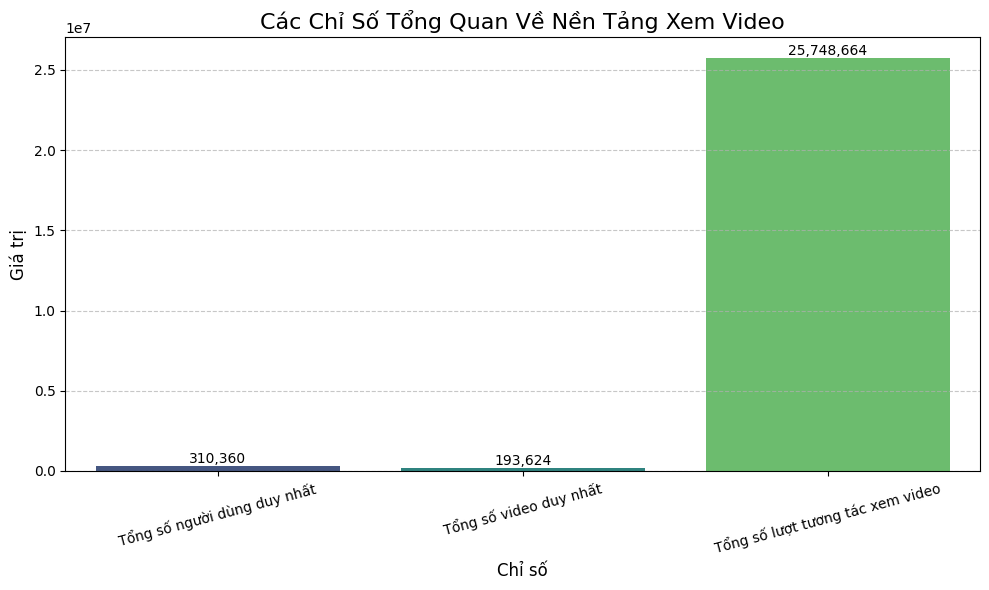

In [ ]:
# Tính toán các chỉ số từ final_flat_df
total_unique_users = final_flat_df['user_id'].n_unique()
total_unique_videos = final_flat_df['video_id'].n_unique()
total_interactions = final_flat_df.height

# In ra để xác nhận
print(f"\nTổng số người dùng duy nhất: {total_unique_users}")
print(f"Tổng số video duy nhất: {total_unique_videos}")
print(f"Tổng số lượt tương tác xem video: {total_interactions}")

## Biểu đồ Thể hiện Các Chỉ Số Tổng Quan

# Tạo DataFrame từ các giá trị đã tính toán
stats_data = {
    'Chỉ số': [
        'Tổng số người dùng duy nhất',
        'Tổng số video duy nhất',
        'Tổng số lượt tương tác xem video'
    ],
    'Giá trị': [
        total_unique_users,
        total_unique_videos,
        total_interactions
    ]
}

stats_df = pd.DataFrame(stats_data)

plt.figure(figsize=(10, 6))
# Sử dụng sns.barplot để tạo biểu đồ cột
sns.barplot(x='Chỉ số', y='Giá trị', data=stats_df, palette='viridis') # 'viridis' là một color palette khác đẹp

# Thêm nhãn giá trị lên trên mỗi cột để dễ đọc
for index, row in stats_df.iterrows():
    plt.text(index, row['Giá trị'], f'{row["Giá trị"]:,.0f}', color='black', ha="center", va='bottom', fontsize=10)

plt.title("Các Chỉ Số Tổng Quan Về Nền Tảng Xem Video", fontsize=16)
plt.xlabel("Chỉ số", fontsize=12)
plt.ylabel("Giá trị", fontsize=12)
plt.xticks(rotation=15) # Xoay nhẹ nhãn trục X để tránh chồng chéo
plt.grid(axis='y', linestyle='--', alpha=0.7) # Thêm lưới ngang cho dễ đọc
plt.tight_layout() # Điều chỉnh bố cục để tránh cắt xén nhãn
plt.show()

In [ ]:
# Tính toán thời lượng xem cho mỗi segment (giả định đơn vị là giây)
df_with_duration = final_flat_df.with_columns(
    (pl.col("end_point") - pl.col("start_point")).alias("segment_duration_seconds")
)
print("\nDataFrame với cột 'segment_duration_seconds' (top 5):")
df_with_duration.head()



DataFrame với cột 'segment_duration_seconds' (top 5):


user_id,video_id,start_point,end_point,playback_speed,timestamp,datetime_utc,hour_of_day,day_of_week,speed_category,segment_duration_seconds
str,str,f64,f64,f64,i64,"datetime[μs, UTC]",i8,i8,str,f64
"""U_112""","""V_1395633""",130.0,190.0,1.0,1588431144,2020-05-02 06:52:24 UTC,6,6,"""normal""",60.0
"""U_112""","""V_1395633""",220.0,250.0,1.0,1588431234,2020-05-02 06:53:54 UTC,6,6,"""normal""",30.0
"""U_112""","""V_1395633""",478.8,508.8,1.0,1588437359,2020-05-02 08:35:59 UTC,8,6,"""normal""",30.0
"""U_112""","""V_1395633""",655.1,692.55,1.25,1588437514,2020-05-02 08:38:34 UTC,8,6,"""fast""",37.45
"""U_112""","""V_1395635""",135.0,170.0,1.0,1588438045,2020-05-02 08:47:25 UTC,8,6,"""normal""",35.0


In [ ]:
# Tổng thời gian xem của mỗi người dùng
total_watch_time_per_user = df_with_duration.group_by("user_id").agg(
    pl.col("segment_duration_seconds").sum().alias("total_watch_time_seconds_per_user")
).sort("total_watch_time_seconds_per_user", descending=True)
print("\nTổng thời gian xem mỗi người dùng (top 5):")
total_watch_time_per_user.head()


Tổng thời gian xem mỗi người dùng (top 5):


user_id,total_watch_time_seconds_per_user
str,f64
"""U_34007795""",641972.0
"""U_35198931""",541749.0
"""U_35198927""",534415.0
"""U_35199212""",503368.0
"""U_35197123""",427699.0


In [ ]:
# Tính toán thời lượng xem cho mỗi segment (giả định đơn vị là giây)
final_flat_df = final_flat_df.with_columns(
    (pl.col("end_point") - pl.col("start_point")).alias("segment_duration_seconds")
)
print("\nDataFrame với cột 'segment_duration_seconds' (top 5):")
final_flat_df.head()



DataFrame với cột 'segment_duration_seconds' (top 5):


user_id,video_id,start_point,end_point,playback_speed,timestamp,datetime_utc,hour_of_day,day_of_week,speed_category,segment_duration_seconds
str,str,f64,f64,f64,i64,"datetime[μs, UTC]",i8,i8,str,f64
"""U_112""","""V_1395633""",130.0,190.0,1.0,1588431144,2020-05-02 06:52:24 UTC,6,6,"""normal""",60.0
"""U_112""","""V_1395633""",220.0,250.0,1.0,1588431234,2020-05-02 06:53:54 UTC,6,6,"""normal""",30.0
"""U_112""","""V_1395633""",478.8,508.8,1.0,1588437359,2020-05-02 08:35:59 UTC,8,6,"""normal""",30.0
"""U_112""","""V_1395633""",655.1,692.55,1.25,1588437514,2020-05-02 08:38:34 UTC,8,6,"""fast""",37.45
"""U_112""","""V_1395635""",135.0,170.0,1.0,1588438045,2020-05-02 08:47:25 UTC,8,6,"""normal""",35.0


In [ ]:
# Chuyển đổi sang Pandas DataFrame để vẽ biểu đồ với Seaborn/Matplotlib
# Chỉ giữ lại các cột cần thiết để tránh lỗi bộ nhớ với DataFrame quá lớn
df_for_plotting = final_flat_df.select([
    "user_id", "video_id", "playback_speed", "segment_duration_seconds", "datetime_utc"
]).to_pandas()

In [ ]:
# Tính toán các DataFrame tổng hợp cần thiết cho biểu đồ (đã là Pandas DF) ---
total_watch_time_per_user_df = final_flat_df.group_by("user_id").agg(
    pl.col("segment_duration_seconds").sum().alias("total_watch_time_seconds_per_user")
).to_pandas()

total_watch_time_per_video_df = final_flat_df.group_by("video_id").agg(
    pl.col("segment_duration_seconds").sum().alias("total_watch_time_seconds_per_video")
).to_pandas()

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


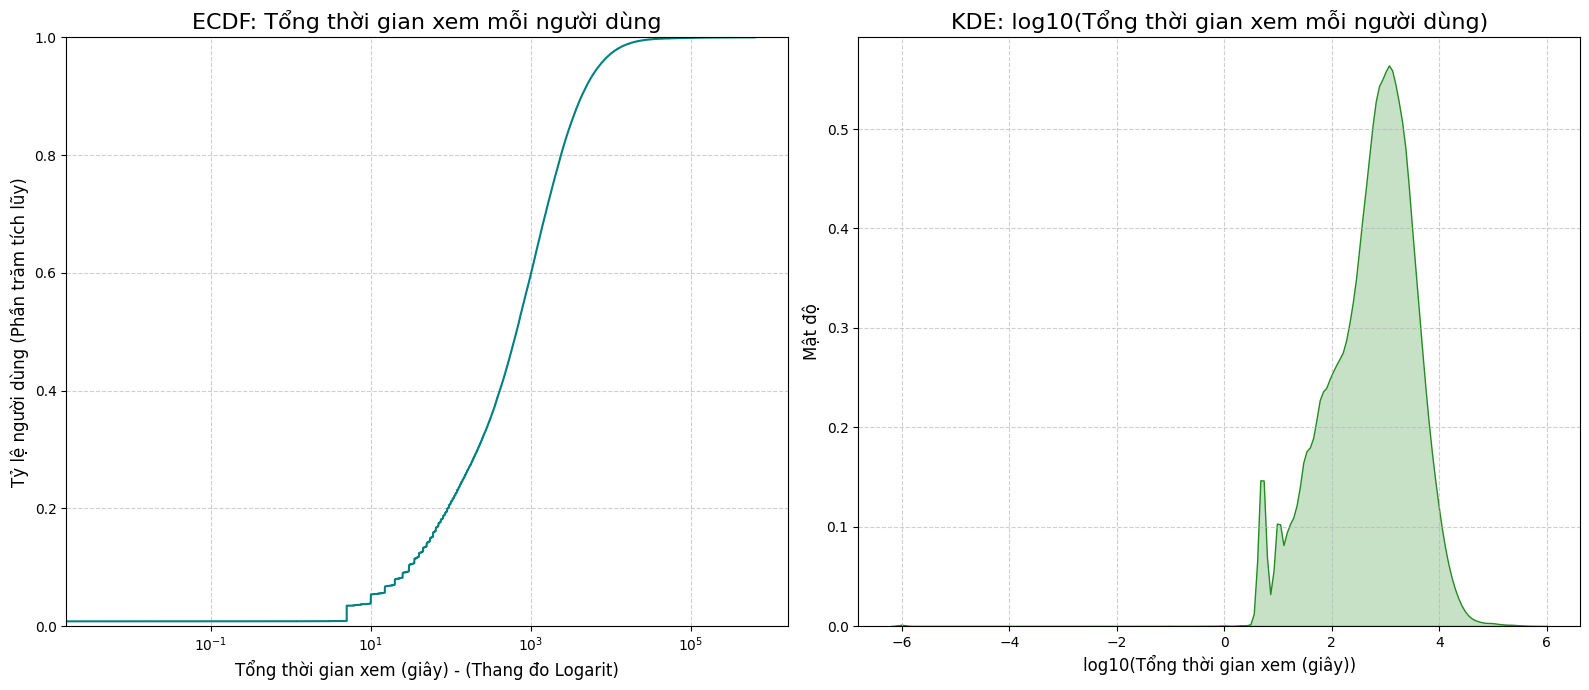

In [ ]:
# Để tránh lỗi log(0) nếu có thời gian xem là 0, thêm một epsilon nhỏ
total_watch_time_per_user_df['total_watch_time_seconds_per_user_log'] = \
    np.log10(total_watch_time_per_user_df['total_watch_time_seconds_per_user'] + 1e-6) # + epsilon nhỏ

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ 1: ECDF Plot
sns.ecdfplot(x='total_watch_time_seconds_per_user', data=total_watch_time_per_user_df, ax=axes[0], color='teal')
axes[0].set_title("ECDF: Tổng thời gian xem mỗi người dùng", fontsize=16)
axes[0].set_xlabel("Tổng thời gian xem (giây) - (Thang đo Logarit)", fontsize=12)
axes[0].set_ylabel("Tỷ lệ người dùng (Phần trăm tích lũy)", fontsize=12)
axes[0].set_xscale('log')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: KDE Plot (trên dữ liệu đã log-transform)
sns.kdeplot(x='total_watch_time_seconds_per_user_log', data=total_watch_time_per_user_df, fill=True, ax=axes[1], color='forestgreen')
axes[1].set_title("KDE: log10(Tổng thời gian xem mỗi người dùng)", fontsize=16)
axes[1].set_xlabel("log10(Tổng thời gian xem (giây))", fontsize=12)
axes[1].set_ylabel("Mật độ", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Tổng thời gian xem của mỗi video
total_watch_time_per_video_df = final_flat_df.group_by("video_id").agg(
    pl.col("segment_duration_seconds").sum().alias("total_watch_time_seconds_per_video")
).sort("total_watch_time_seconds_per_video", descending=True)
print("\nTổng thời gian xem mỗi video (top 5):")
total_watch_time_per_video_df.head()


Tổng thời gian xem mỗi video (top 5):


video_id,total_watch_time_seconds_per_video
str,f64
"""V_1395633""",6.1607e6
"""V_1395641""",3.7130e6
"""V_1358540""",2.0535e6
"""V_1358564""",1.7825e6
"""V_1358544""",1.6229e6


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


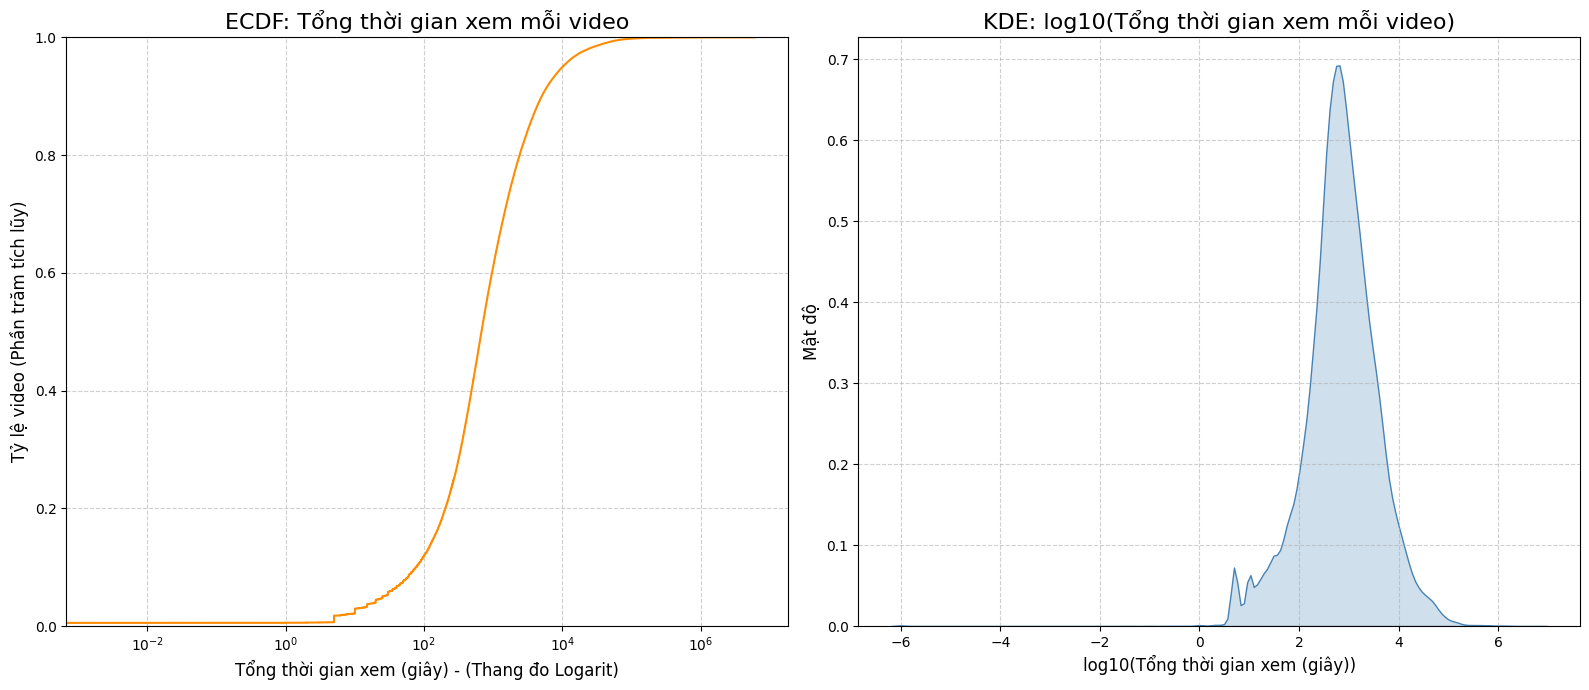

In [ ]:
# Tạo cột log bằng with_columns (Polars cách)
total_watch_time_per_video_df = total_watch_time_per_video_df.with_columns(
    (pl.col("total_watch_time_seconds_per_video") + 1e-6).log10().alias("total_watch_time_seconds_per_video_log")
)

# Chuyển sang Pandas để vẽ biểu đồ
total_watch_time_per_video_df = total_watch_time_per_video_df.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ 1: ECDF Plot
sns.ecdfplot(x='total_watch_time_seconds_per_video', data=total_watch_time_per_video_df, ax=axes[0], color='darkorange')
axes[0].set_title("ECDF: Tổng thời gian xem mỗi video", fontsize=16)
axes[0].set_xlabel("Tổng thời gian xem (giây) - (Thang đo Logarit)", fontsize=12)
axes[0].set_ylabel("Tỷ lệ video (Phần trăm tích lũy)", fontsize=12)
axes[0].set_xscale('log')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: KDE Plot (log-transform)
sns.kdeplot(x='total_watch_time_seconds_per_video_log', data=total_watch_time_per_video_df, fill=True, ax=axes[1], color='steelblue')
axes[1].set_title("KDE: log10(Tổng thời gian xem mỗi video)", fontsize=16)
axes[1].set_xlabel("log10(Tổng thời gian xem (giây))", fontsize=12)
axes[1].set_ylabel("Mật độ", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

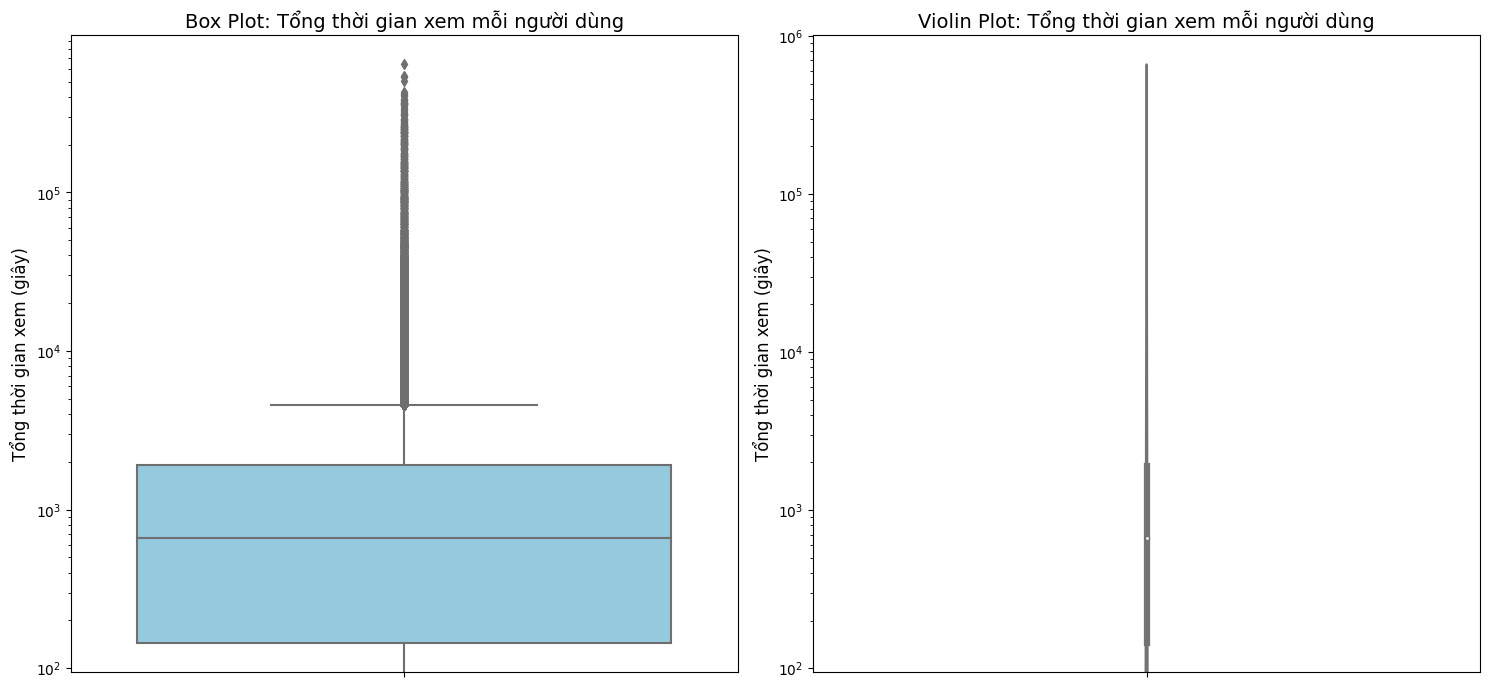

In [ ]:
# Tính tổng thời gian xem mỗi người dùng
total_watch_time_per_user_df = final_flat_df.group_by("user_id").agg(
    pl.col("segment_duration_seconds").sum().alias("total_watch_time_seconds_per_user")
).to_pandas()

# Tạo 2 biểu đồ trên cùng một figure
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Biểu đồ 1: Box Plot
sns.boxplot(y=total_watch_time_per_user_df['total_watch_time_seconds_per_user'], ax=axes[0], color='skyblue')
axes[0].set_title("Box Plot: Tổng thời gian xem mỗi người dùng", fontsize=14)
axes[0].set_ylabel("Tổng thời gian xem (giây)", fontsize=12)
axes[0].set_yscale('log') # Áp dụng thang đo logarit cho trục Y

# Biểu đồ 2: Violin Plot
sns.violinplot(y=total_watch_time_per_user_df['total_watch_time_seconds_per_user'], ax=axes[1], color='lightgreen')
axes[1].set_title("Violin Plot: Tổng thời gian xem mỗi người dùng", fontsize=14)
axes[1].set_ylabel("Tổng thời gian xem (giây)", fontsize=12)
axes[1].set_yscale('log') # Áp dụng thang đo logarit cho trục Y

plt.tight_layout()
plt.show()

In [ ]:
# Phân bố tốc độ phát lại
print("\nPhân bố tốc độ phát lại video:")
playback_speed_dist = final_flat_df.group_by("playback_speed").agg(
    pl.len().alias("num_segments")
).sort("playback_speed")
playback_speed_dist


Phân bố tốc độ phát lại video:


playback_speed,num_segments
f64,u32
0.5,2560
1.0,20348286
1.25,628161
1.5,722585
2.0,4047072


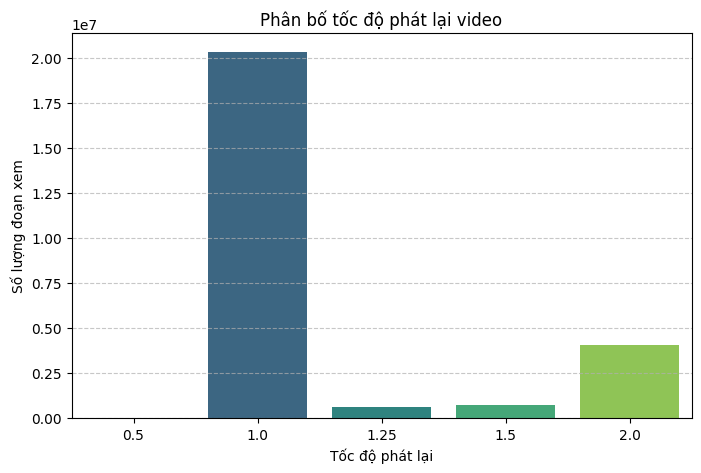

In [ ]:
# Tính phân bố tốc độ phát lại
playback_speed_dist_df = final_flat_df.group_by("playback_speed").agg(
    pl.len().alias("num_segments")
).sort("playback_speed").to_pandas() # Chuyển sang pandas để vẽ biểu đồ

plt.figure(figsize=(8, 5))
sns.barplot(x='playback_speed', y='num_segments', data=playback_speed_dist_df, palette='viridis')
plt.title("Phân bố tốc độ phát lại video")
plt.xlabel("Tốc độ phát lại")
plt.ylabel("Số lượng đoạn xem")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Số lượng segment trung bình mỗi video
avg_segments_per_video = final_flat_df.group_by("video_id").agg(
    pl.len().alias("num_segments_in_video")
).select(pl.col("num_segments_in_video").mean().alias("avg_segments_per_video"))
print(f"\nSố lượng segment trung bình mỗi video: {avg_segments_per_video.item()}")


Số lượng segment trung bình mỗi video: 132.98281204809322



Số lượng segment trung bình trên tất cả các video: 132.98


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


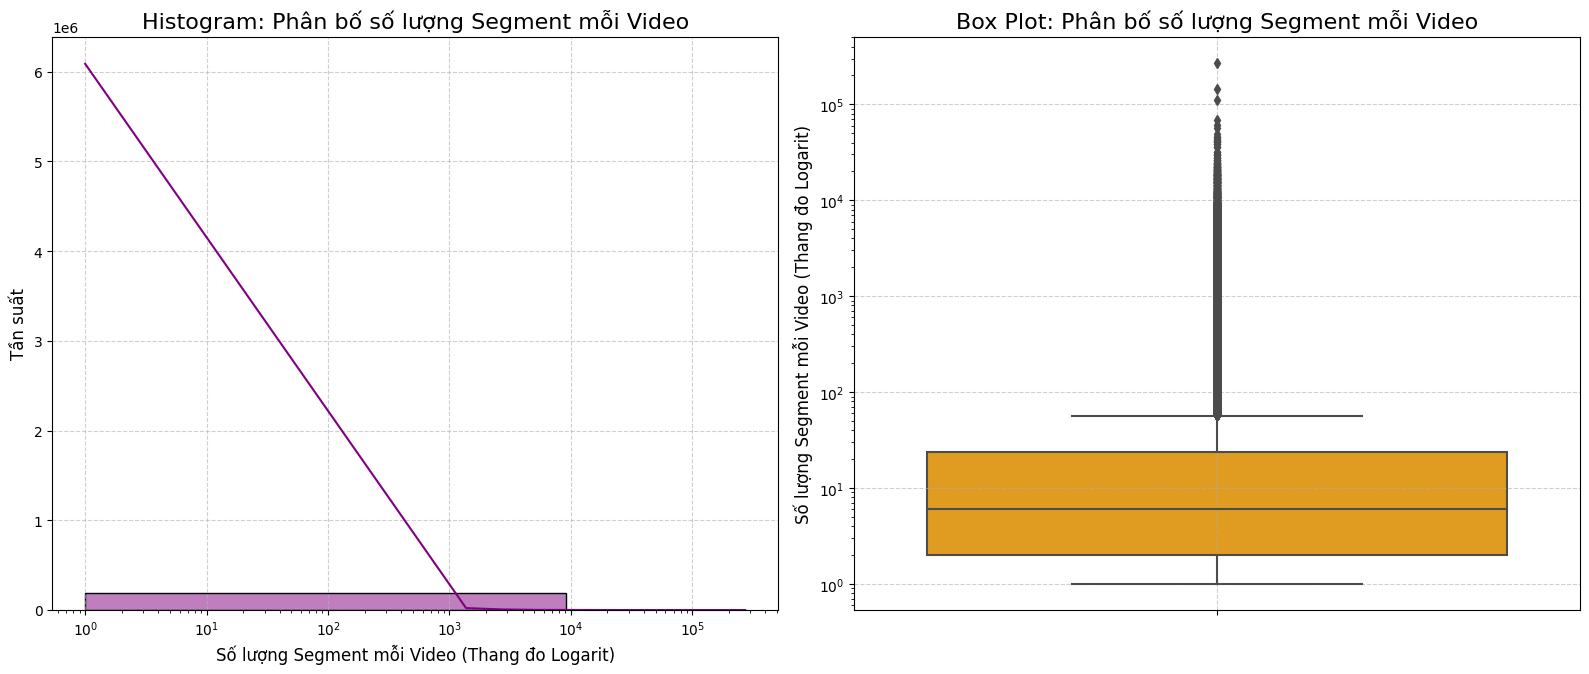

In [ ]:
# Tính toán số lượng segment cho mỗi video
# Đếm số lần xuất hiện của mỗi video_id, mỗi lần xuất hiện là một segment
segment_count_per_video_df = final_flat_df.group_by("video_id").agg(
    pl.len().alias("segment_count_per_video") # len() ở đây đếm số hàng (segment) cho mỗi video_id
).to_pandas()

# Tính "trung bình" của số segment trên *tất cả* các video
average_segments_overall = segment_count_per_video_df['segment_count_per_video'].mean()
print(f"\nSố lượng segment trung bình trên tất cả các video: {average_segments_overall:.2f}")


# Để tránh lỗi log(0) nếu có giá trị là 0, thêm một epsilon nhỏ khi log-transform
# Mặc dù số segment thường không phải là 0, nhưng đây là một biện pháp an toàn.
segment_count_per_video_df['segment_count_per_video_log'] = \
    np.log10(segment_count_per_video_df['segment_count_per_video'] + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ 1: Histogram của Số lượng Segment mỗi Video (trên thang đo logarit)
sns.histplot(x='segment_count_per_video', data=segment_count_per_video_df, ax=axes[0], bins=30, kde=True, color='purple')
axes[0].set_title("Histogram: Phân bố số lượng Segment mỗi Video", fontsize=16)
axes[0].set_xlabel("Số lượng Segment mỗi Video (Thang đo Logarit)", fontsize=12)
axes[0].set_ylabel("Tần suất", fontsize=12)
axes[0].set_xscale('log') # Áp dụng thang đo logarit cho trục X
axes[0].grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Box Plot của Số lượng Segment mỗi Video (trên thang đo logarit)
sns.boxplot(y='segment_count_per_video', data=segment_count_per_video_df, ax=axes[1], color='orange')
axes[1].set_title("Box Plot: Phân bố số lượng Segment mỗi Video", fontsize=16)
axes[1].set_ylabel("Số lượng Segment mỗi Video (Thang đo Logarit)", fontsize=12)
axes[1].set_yscale('log') # Áp dụng thang đo logarit cho trục Y
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Hoạt động xem video theo thời gian (theo ngày)
df_by_day = final_flat_df.with_columns(
    pl.col("datetime_utc").dt.date().alias("view_date")
)
daily_views = df_by_day.group_by("view_date").agg(
    pl.len().alias("total_views")
).sort("view_date")
print("\nTổng số lượt xem theo ngày (top 5):")
daily_views.head()



Tổng số lượt xem theo ngày (top 5):


view_date,total_views
date,u32
2001-12-31,14
2006-06-30,18
2006-07-01,10
2008-12-31,7
2009-12-31,3


In [ ]:
# Video nào được xem nhiều nhất (dựa trên số lượng segment tương tác)
top_videos_by_segments = final_flat_df.group_by("video_id").agg(
    pl.len().alias("total_segments_viewed")
).sort("total_segments_viewed", descending=True).head(10)
print("\nTop 10 video được xem nhiều segment nhất:")
top_videos_by_segments


Top 10 video được xem nhiều segment nhất:


video_id,total_segments_viewed
str,u32
"""V_1395633""",272469
"""V_1395641""",145247
"""V_1395634""",109913
"""V_1358540""",68423
"""V_1395635""",61498
"""V_1395643""",56593
"""V_1395645""",48945
"""V_1395636""",45688
"""V_1395638""",45593


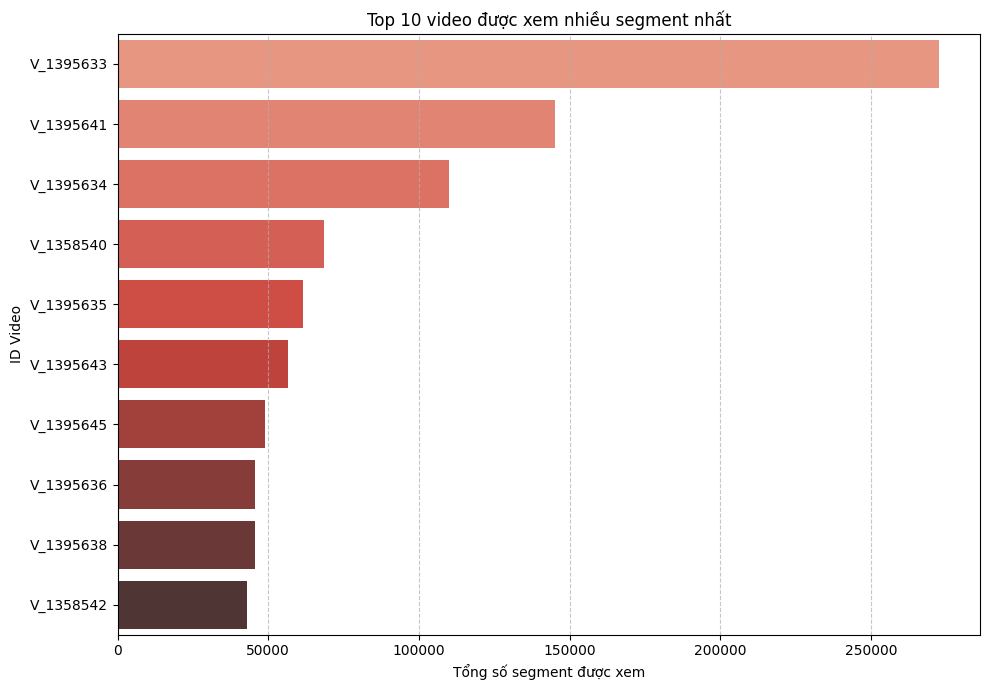

In [ ]:
# Tính Top 10 video được xem nhiều segment nhất
top_videos_by_segments_df = final_flat_df.group_by("video_id").agg(
    pl.len().alias("total_segments_viewed")
).sort("total_segments_viewed", descending=True).head(10).to_pandas() # Chuyển sang pandas

plt.figure(figsize=(10, 7))
sns.barplot(x='total_segments_viewed', y='video_id', data=top_videos_by_segments_df, palette='Reds_d')
plt.title("Top 10 video được xem nhiều segment nhất")
plt.xlabel("Tổng số segment được xem")
plt.ylabel("ID Video")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
final_flat_df.write_csv("clean_user_video.csv")
print("Đã xuất file sạch")

Đã xuất file sạch


In [ ]:
final_flat_df.he